# Model B — Deeper CNN

In this notebook we evaluates the effect of increasing CNN depth. In Model A we used two convolutional blocks with filters 32 and 64.  


In Model B we will add a third convolutional block with 128 filters and all other training conditions are kept identical for a fair comparison, 
our goal in this part is to test depth impact . 

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification


In [2]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from project_utils import (
    SEED,
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_cnn,
)

In [3]:
set_seed()
train_ds, val_ds, test_ds = load_datasets()

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


In [ ]:
# Model B configuration: deeper CNN with three convolutional blocks
model_b_config = {
    "name": "model_b_deeper",
    "filters": [32, 64, 128],
    "kernel_size": 3,
    "augmentation": False,
    "batch_norm": False,
    "dense_units": 64,
    "dropout": 0.0,
}

In [5]:
tf.keras.backend.clear_session()
set_seed()

model_b = build_cnn(
    num_classes=len(TARGET_CLASSES),
    config=model_b_config,
)

model_b.summary()

model_b_params = model_b.count_params()

print(f"Total parameters: {model_b_params:,}")

Model: "model_b_deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,154 (399.04 KB)

 Trainable params: 102,154 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 102,154


In [ ]:
#model compile
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
#model training
start = time.time()

history_b = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2
)

train_time_sec_b = time.time() - start

print(f"\nTraining time: {train_time_sec_b:.1f} sec for {EPOCHS} epochs")

Epoch 1/15


/Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 - 15s - 190ms/step - accuracy: 0.1920 - loss: 2.1149 - val_accuracy: 0.3277 - val_loss: 1.7443
Epoch 2/15
77/77 - 15s - 189ms/step - accuracy: 0.4371 - loss: 1.5240 - val_accuracy: 0.4640 - val_loss: 1.3444
Epoch 3/15
77/77 - 15s - 193ms/step - accuracy: 0.5158 - loss: 1.3156 - val_accuracy: 0.3845 - val_loss: 1.5837
Epoch 4/15
77/77 - 15s - 195ms/step - accuracy: 0.5264 - loss: 1.2798 - val_accuracy: 0.5549 - val_loss: 1.2448
Epoch 5/15
77/77 - 15s - 196ms/step - accuracy: 0.5678 - loss: 1.1808 - val_accuracy: 0.5473 - val_loss: 1.1540
Epoch 6/15
77/77 - 16s - 202ms/step - accuracy: 0.5942 - loss: 1.1037 - val_accuracy: 0.6080 - val_loss: 1.0643
Epoch 7/15
77/77 - 16s - 203ms/step - accuracy: 0.6023 - loss: 1.0755 - val_accuracy: 0.6174 - val_loss: 1.0255
Epoch 8/15
77/77 - 16s - 210ms/step - accuracy: 0.6254 - loss: 1.0395 - val_accuracy: 0.5208 - val_loss: 1.2818
Epoch 9/15
77/77 - 17s - 224ms/step - accuracy: 0.6295 - loss: 1.0165 - val_accuracy: 0.6383 - val_loss: 0.9955
Epo

Model B test accuracy: 0.6837
Model B test loss: 0.8782


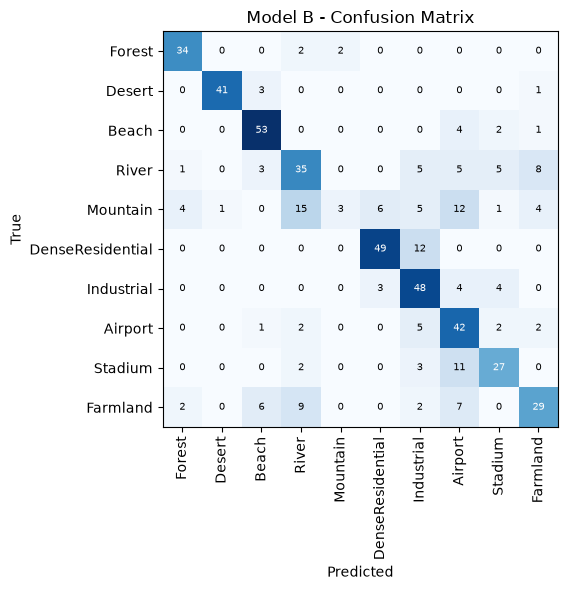

                  precision    recall  f1-score   support

          Forest       0.83      0.89      0.86        38
          Desert       0.98      0.91      0.94        45
           Beach       0.80      0.88      0.84        60
           River       0.54      0.56      0.55        62
        Mountain       0.60      0.06      0.11        51
DenseResidential       0.84      0.80      0.82        61
      Industrial       0.60      0.81      0.69        59
         Airport       0.49      0.78      0.60        54
         Stadium       0.66      0.63      0.64        43
        Farmland       0.64      0.53      0.58        55

        accuracy                           0.68       528
       macro avg       0.70      0.69      0.66       528
    weighted avg       0.69      0.68      0.66       528



In [ ]:
#model evaluation and results visualization
test_loss_b, test_acc_b = model_b.evaluate(test_ds, verbose=0)

print(f"Model B test accuracy: {test_acc_b:.4f}")
print(f"Model B test loss: {test_loss_b:.4f}")


y_true_b = []
y_pred_b = []

for imgs, labels in test_ds:
    probs = model_b.predict(imgs, verbose=0)

    y_true_b.extend(labels.numpy().tolist())
    y_pred_b.extend(np.argmax(probs, axis=1).tolist())


cm_b = confusion_matrix(y_true_b, y_pred_b)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm_b, cmap="Blues")

ax.set_xticks(range(len(TARGET_CLASSES)))
ax.set_xticklabels(TARGET_CLASSES, rotation=90)

ax.set_yticks(range(len(TARGET_CLASSES)))
ax.set_yticklabels(TARGET_CLASSES)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Model B - Confusion Matrix")

for i in range(cm_b.shape[0]):
    for j in range(cm_b.shape[1]):
        ax.text(
            j,
            i,
            cm_b[i, j],
            ha="center",
            va="center",
            color="white" if cm_b[i, j] > cm_b.max() / 2 else "black",
            fontsize=7
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_b_confusion_matrix.png",
    dpi=120
)

plt.show()


print(
    classification_report(
        y_true_b,
        y_pred_b,
        target_names=TARGET_CLASSES
    )
)

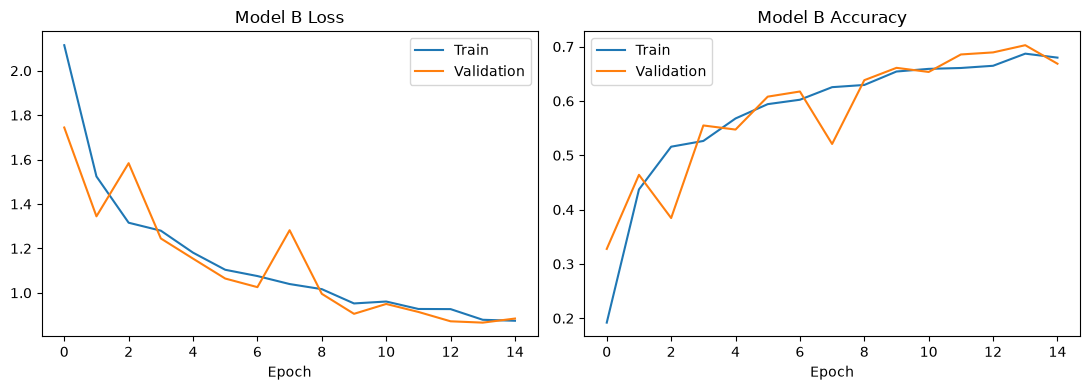

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)

axes[0].plot(
    history_b.history["loss"],
    label="Train",
)

axes[0].plot(
    history_b.history["val_loss"],
    label="Validation",
)

axes[0].set_title("Model B Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    history_b.history["accuracy"],
    label="Train",
)

axes[1].plot(
    history_b.history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Model B Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#save the model configuration and results in the "reslts" directory 
model_b.save(
    ARTIFACTS_DIR / "model_b_deeper.keras"
)

n_params_b = model_b.count_params()

history_out_b = {
    "model": "model_b_deeper",
    "config": model_b_config,
    "epochs": EPOCHS,
    "train_time_sec": float(train_time_sec_b),
    "n_params": int(n_params_b),
    "test_accuracy": float(test_acc_b),
    "test_loss": float(test_loss_b),
    "history": {
        k: [float(v) for v in vals]
        for k, vals in history_b.history.items()
    },
}

with open(
    RESULTS_DIR / "model_b_history.json",
    "w"
) as f:
    json.dump(history_out_b, f, indent=2)


print(
    "Saved model to",
    ARTIFACTS_DIR / "model_b_deeper.keras"
)

print(
    "Saved training history to",
    RESULTS_DIR / "model_b_history.json"
)

Saved model to /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/artifacts/model_b_deeper.keras
Saved training history to /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/results/model_b_history.json


## Findings
Model B increased the CNN depth from two to three convolutional blocks using progressive filters (32 → 64 → 128).

The deeper architecture improved test accuracy from 63.64% in Model A to 68.37%, while test loss decreased from 1.0350 to 0.8782.
Macro F1 also improved from 0.62 to 0.66 , while training and validation accuracy remained close, indicating no significant
overfitting. Most classes improved, particularly Stadium, Beach, and Industrial. However, Mountain remained difficult and its F1-score decreased
to 0.11.

Overall, increasing CNN depth improved feature extraction and classification performance, but some classes still require further improvement.